#1. Load Libraries and Clean Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
import os

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)

# Load the interim cleaned data from 01_eda step
df = pd.read_csv("../data/processed/telecom_clean.csv")
df.head()

,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,total_charges,avg_data_gb_month,avg_voice_mins_month,sms_count_month,overage_charges,is_family_plan,is_multi_service,network_issues_3m,call_drop_rate,avg_data_speed_mbps,complaints_3m,num_complaints_12m,call_center_interactions_3m,last_complaint_resolution_days,app_logins_30d,selfcare_transactions_30d,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn,log_charges
0,100000,Female,23,West,4G,Postpaid,2 Year,Postpaid Platinum,84,1133.57,92927.66,10.69,453.0,102.0,0.00,1,0,1,0.035772,20.657628,1,1,2,3.3,8,3,0,0,0.4,1133.57,High,13.0,3.2,0,0,0,7.034009
1,100001,Male,72,West,4G,Prepaid,No Contract,Prepaid Unlimited,32,683.24,19368.90,34.65,797.0,29.0,169.54,0,1,3,0.015473,11.957035,0,0,1,0.0,6,2,0,1,5.4,688.54,Medium,41.0,3.6,0,0,0,6.528309
2,100002,Female,47,South,4G,Prepaid,No Contract,Prepaid Regular,119,307.04,36123.77,5.22,687.0,73.0,0.74,0,0,1,0.028856,21.120911,1,3,2,5.4,5,3,1,0,0.0,307.05,Low,53.0,5.0,0,0,0,5.730230
3,100003,Female,74,West,4G,Prepaid,No Contract,Prepaid Mini,73,213.82,16476.90,24.49,232.0,0.0,78.21,1,0,0,0.033661,16.733437,0,1,0,0.0,7,5,1,0,0.0,214.89,Low,20.0,4.5,1,1,0,5.369800
4,100004,Male,41,South,5G,Prepaid,No Contract,Prepaid Regular,92,383.17,37683.17,50.46,450.0,35.0,75.60,0,0,5,0.013339,8.692907,0,0,0,0.0,6,4,0,0,0.5,383.99,Low,17.0,2.6,0,0,0,5.951085


#2. Feature Engineering: Usage & Charge Deviations

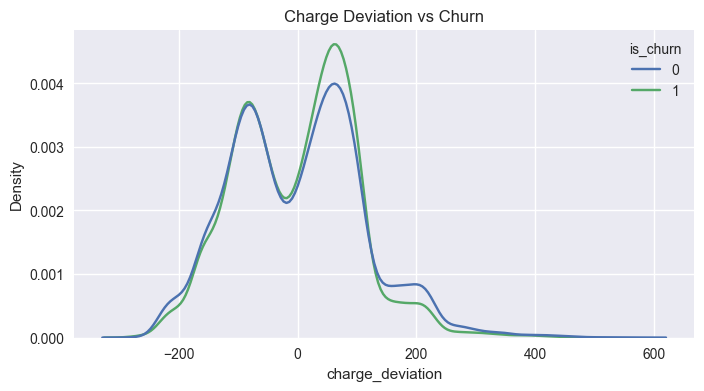

In [18]:
# Create segment baseline for monthly charges
segment_avg_charge = df.groupby("segment_value")["monthly_charges"].transform("mean")
df["charge_deviation"] = df["monthly_charges"] - segment_avg_charge

# Usage Intensity: Data usage relative to how long they've been with the company
df["usage_intensity"] = df["avg_data_gb_month"] / (df["tenure_months"] + 1)

# Visualize how deviation impacts churn
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="charge_deviation", hue="is_churn", common_norm=False)
plt.title("Charge Deviation vs Churn")
plt.show()

#3. Service Pressure Features

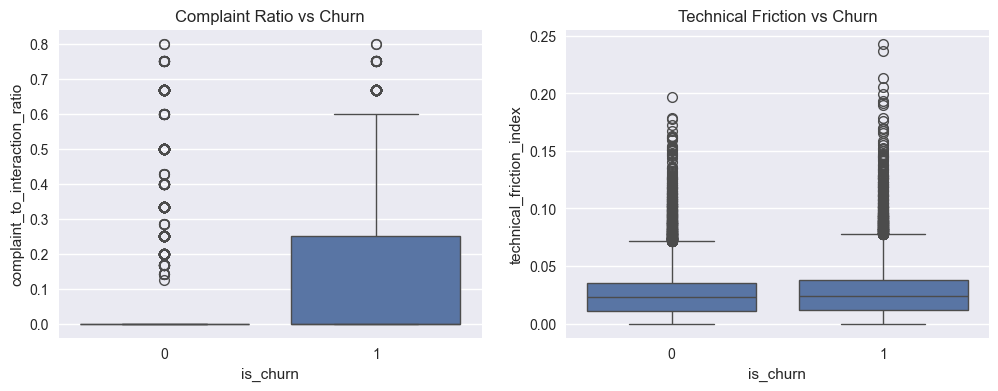

In [19]:
# Ratio of complaints to call center interactions
df["complaint_to_interaction_ratio"] = df["complaints_3m"] / (df["call_center_interactions_3m"] + 1)

# High Drop Rate + High Complaints = High Churn Risk
df["technical_friction_index"] = df["call_drop_rate"] * (df["complaints_3m"] + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="is_churn", y="complaint_to_interaction_ratio", data=df, ax=axes[0])
axes[0].set_title("Complaint Ratio vs Churn")

sns.boxplot(x="is_churn", y="technical_friction_index", data=df, ax=axes[1])
axes[1].set_title("Technical Friction vs Churn")
plt.show()

#4. Combined Churn Risk Index

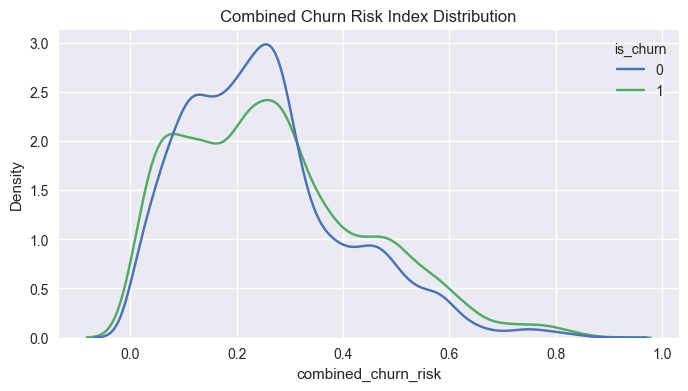

In [20]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- ADD THIS PART TO FIX THE ERROR ---
output_plot_dir = "output/plots"
os.makedirs(output_plot_dir, exist_ok=True)
# --------------------------------------

# Normalize components to 0-1 scale for the index
df["combined_churn_risk"] = (
    0.3 * (df["nps_score"].rank(pct=True)) +  
    0.3 * df["received_competitor_offer_flag"] +
    0.2 * (df["num_complaints_12m"] / (df["num_complaints_12m"].max() + 1e-3)) + 
    0.2 * df["late_payment_flag_3m"]
)

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="combined_churn_risk", hue="is_churn", common_norm=False)
plt.title("Combined Churn Risk Index Distribution")

# Saving the chart to your output folder
plt.savefig(os.path.join(output_plot_dir, "06_combined_risk_index.png"), dpi=300, bbox_inches='tight')
plt.show()

#5. Model Test & Feature Importance

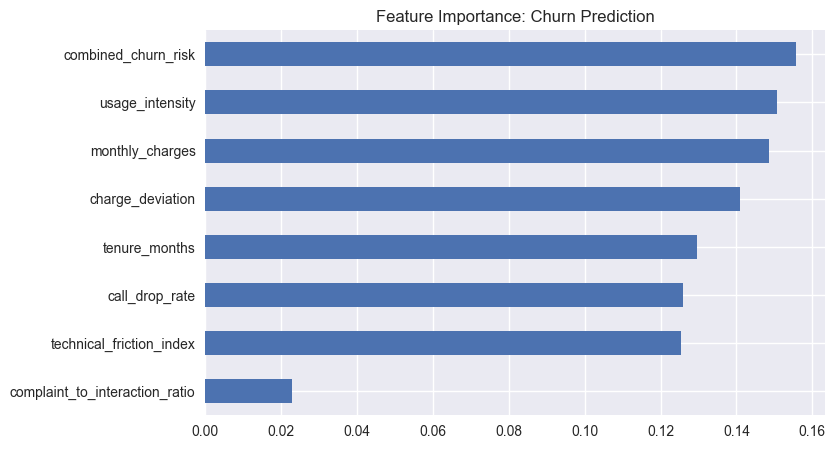

ROC AUC Score: 0.5589


In [21]:
# Define features including new engineered ones
feature_cols = [
    "monthly_charges", "tenure_months", "call_drop_rate",
    "charge_deviation", "usage_intensity", "technical_friction_index",
    "complaint_to_interaction_ratio", "combined_churn_risk"
]

X = df[feature_cols].fillna(0)
y = df["is_churn"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train model
clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)

# Importance
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Feature Importance: Churn Prediction")
plt.gca().invert_yaxis()
plt.show()

print(f"ROC AUC Score: {roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1]):.4f}")

#6. Save Engineered Data

In [22]:
output_dir = "../data/interim"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "telecom_features.csv")

df.to_csv(output_path, index=False)
print(f"Feature development complete. Saved to: {output_path}")

Feature development complete. Saved to: ../data/interim\telecom_features.csv
